# 8.1 DAACS

## Data Creation

### Item 1

I downloaded the Stewart Castle Village basic inventory from the DAACS “Query the Database” tool and selected the "Artifact Queries" option. Then, I selected the "Basic Inventory" query, checked the box that said "Stewart Castle Village", and submitted the query after keeping step 2 as default. 

Provenance is “as exported from DAACS for Stewart Castle Village on 3/22/2026.”

### Item 2

3 free points.

### Item 3

Bias can enter in multiple stages of the data collection process because excavation and recovery practices differ by context and unit type. Therefore, the "Total Count" is “recovered and recorded under those conditions,” instead of neutrally. Artifact Type and Artifact Category reflect typological decisions made before or during database entry by the archaeologists. The same object might be classified differently across different projects or analysts. In addition, many stratigraphic and feature fields are blank on these rows when the query does not populate them, which can hide structure that would matter for interpretation. That's why DAACS' way of standardization is to use comparable fields, but not identical formation processes behind each cell.

### Item 4

There are a lot of ways to mitigate the bias. First, treat this export as a Basic Inventory slice for one site only; do not treat counts as comparable to other sites without checking field and recovery documentation. When it comes to data analysis, adhere to this file’s definitions and, and retain the context, deposit type, unit type, and phase in mind so you do not imply a single homogeneous assemblage. 

Second, it's important to refer to DAACS and Stewart Castle Village documentation to interpret sparse columns (empty feature or stratigraphic fields) instead of assuming “missing means absent.”

### Item 5

I acquired the Stewart Castle Village dataset by subsequently selecting "Artifact Queries", "Basic Inventory", and the default setting for step 2. The file is one flat table; I rename a few fields so the sample R code’s names match the export (counts and the three grouping variables). The main judgement calls are following the query’s default filters and the inventory row grain; uncertainty is mostly typology, empty optional fields, and whether the export is complete. ~1,706 data rows line up with the ~1,705 hint and act as a sanity check on the download.

## Metadata

### Item 1

| Attribute | Data type | Description |
|-----------|-----------|-------------|
| **inventory_line_pk** | **composite (PK)** | Primary key only: combines Project ID, Context, Deposit Type, Unit Type, DAACS Phase, Artifact Type, and Artifact Category to identify one Basic Inventory row. |
| Project Name | text | DAACS project name. |
| Project ID | integer | DAACS project identifier. |
| Context | text | Excavation context. |
| Deposit Type | text | Deposit classification. |
| Unit Type | text | Spatial unit type. |
| Feature Type | text | Feature category when recorded. |
| Feature Number | text | Feature identifier when recorded. |
| Feature Group | text | Feature grouping when recorded. |
| Feature Group Interpretation | text | Interpretive label for feature group. |
| DAACS Stratigraphic Group | text | Stratigraphic group when populated. |
| DAACS Stratigraphic Group Interpretation | text | Interpretation of stratigraphic group. |
| DAACS Phase | text | Phase assignment. |
| Total Count | integer | Artifact count for the line. |
| Artifact Type | text | Specific artifact type string. |
| Artifact Category | text | Broader artifact category. |

### Item 2

| Table | Brief description | Path |
|-------|-------------------|------|
| SCV_BASIC_INVENTORY | Stewart Castle Village rows from DAACS Basic Inventory; 1 header row + 1,706 data rows. | `HW8/aq_one_results_1774229447.csv` |

### Item 3

| Name | Data type | Description | Example |
|------|-----------|-------------|---------|
| Project Name | text | DAACS project label. | Stewart Castle Village |
| Project ID | integer | DAACS numeric project id. | 1210 |
| Context | text | Excavation context / provenience code. | 001A |
| Deposit Type | text | Deposit classification for that line. | Topsoil |
| Unit Type | text | Type of spatial unit the count applies to. | Quadrat/Unit |
| Feature Type | text | Feature category when recorded. | *(empty)* |
| Feature Number | text | Feature identifier when recorded. | *(empty)* |
| Feature Group | text | Feature grouping when recorded. | *(empty)* |
| Feature Group Interpretation | text | Interpretive label for feature group. | *(empty)* |
| DAACS Stratigraphic Group | text | Stratigraphic group when populated. | *(empty)* |
| DAACS Stratigraphic Group Interpretation | text | Interpretation of stratigraphic group. | *(empty)* |
| DAACS Phase | text | Phase assignment for the line. | P02 |
| Total Count | integer | Count of artifacts for this inventory line. | 12 |
| Artifact Type | text | Specific artifact type string. | Pearlware |
| Artifact Category | text | Broader material/category class. | Ceramic |

### Item 4

| Numerical feature | Main uncertainty | How to quantify / report |
|-------------------|------------------|---------------------------|
| Total Count | Integer tally tied to context, deposit, unit type, and typology; not a repeated measurement. | Give sums and proportions at fixed row grain; report how many rows have missing phase/feature/stratigraphic fields; do not imply sub-count precision; when comparing subsets, state row denominators and missingness. |

## Pipeline Check

### Item 1

The workshop script is adapted below: CSV path matches this folder, column names are renamed to match `RWorkshop1_SCV.R`, then `str()` and the same `dplyr` summaries as the sample code. Output is printed when this cell runs.

In [1]:
suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
})

csv_path <- "aq_one_results_1774229447.csv"
StewartCastleVillage <- read.csv(csv_path, stringsAsFactors = FALSE, check.names = FALSE, fileEncoding = "UTF-8")
names(StewartCastleVillage) <- sub("^\uFEFF", "", names(StewartCastleVillage))
names(StewartCastleVillage) <- trimws(names(StewartCastleVillage))

StewartCastleVillage <- StewartCastleVillage %>%
  rename(
    Count = `Total Count`,
    ArtifactCategory = `Artifact Category`,
    ArtifactType = `Artifact Type`,
    UnitType = `Unit Type`
  )

str(StewartCastleVillage)

SCVTotalArts <- StewartCastleVillage %>% summarise(TotalArtifacts = sum(Count))
print(SCVTotalArts)

SCVArtCat <- StewartCastleVillage %>% group_by(ArtifactCategory) %>% summarise(Count = sum(Count))
print(SCVArtCat)

SCVArtType <- StewartCastleVillage %>% group_by(ArtifactType) %>% summarise(Count = sum(Count))
print(head(SCVArtType, 25))

SCVUnitType <- StewartCastleVillage %>% group_by(UnitType) %>% summarise(ArtifactCount = sum(Count))
print(SCVUnitType)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3774603056.py, line 2)

### Item 2

The **correct answer** for the pipeline check is the same end product as the workshop: relative frequencies by `ArtifactCategory` with the ggplot bar chart. After running the cell below you should see the plot below (and the printed `SCVArtFreq` table matches the bar heights).

In [ ]:
SCVArtFreq <- StewartCastleVillage %>%
  group_by(ArtifactCategory) %>%
  summarise(Count = sum(Count)) %>%
  mutate(Percent = Count / sum(Count))

print(SCVArtFreq)

theme_set(theme_bw(base_size = 20))
ggplot(SCVArtFreq, aes(x = ArtifactCategory, y = Percent, fill = ArtifactCategory)) +
  geom_bar(stat = "identity", show.legend = FALSE) +
  scale_fill_manual(values = c(
    "#BBE1FA", "#3282B8", "#0F4C75", "blue", "green",
    "purple", "red", "orange", "black", "green"
  ))

# 8.2 Project 1

## Data Creation

### Item 1

I created a Project 1 dataset for next-day FAANG return modeling using public daily market data from Stooq (https://stooq.com). I pulled daily OHLCV files for META, AAPL, AMZN, NFLX, and GOOGL over 2019-01-01 to 2024-12-31, then standardized and filtered them into a relational dataset.

The final dataset is D1 with four CSV tables (`tickers`, `daily_prices`, `daily_features`, `calendar`) under `Project1/data/`. The feature table is derived from prices using lagged return, rolling volatility, moving-average levels/deviations, and next-day return target fields.

### Item 2

| File | Brief description | Link |
|------|-------------------|------|
| `build_project1_data.py` | Downloads Stooq daily OHLCV data and builds the four relational CSV tables for D1. | [build_project1_data.py](https://github.com/dylanlidailin/DS4320/tree/main/Project1/data/build_project1_data.py) |
| Pipeline notebook cell(s) in this HW | Loads CSV tables into DuckDB, joins features, fits a baseline model, and visualizes feature coefficients. | [data folder](https://github.com/dylanlidailin/DS4320/tree/main/Project1/data) |

### Item 3

Bias can be introduced because this dataset only includes five large U.S. tech stocks (FAANG), so it is not representative of the full equity market. The period (2019-2024) contains unusual market regimes (pandemic crash/rebound, rate shocks), which can distort learned relationships. Data source conventions also matter: vendor-specific handling of splits, bad ticks, and symbol mapping can introduce systematic differences. Finally, engineered features based only on price/volume exclude fundamentals, macro variables, and news flow, which can create omitted-variable bias in downstream modeling.

### Item 4

I mitigate these biases by using strict time-based train/test splits (past to future only), retaining symbol/date keys so rows are traceable back to raw prices, and documenting every transformation from raw OHLCV to engineered features. I also frame results as a proof-of-concept for this specific FAANG slice rather than universal market prediction. In analysis, I report out-of-sample metrics and interpret model outputs cautiously as weak signals, not causal effects.

### Item 5

Key judgement calls were: (1) using Stooq as a free reproducible source, (2) restricting to FAANG for consistency with the project scope, (3) setting the date window to 2019-2024, and (4) creating a normalized four-table schema instead of one flat file. I also explicitly chose a simple baseline feature set and a next-day-return target so the pipeline remains transparent and reproducible.

Main uncertainty comes from market non-stationarity (relationships change over time), potential vendor differences in historical pricing conventions, and sensitivity of short-horizon return models to feature definitions and split boundaries.

## Metadata

### Item 1

| Table | Primary key | Key relationships |
|------|-------------|-------------------|
| `tickers` | `ticker_id` | Parent table for symbols used by `daily_prices` and `daily_features`. |
| `daily_prices` | `price_id` | `ticker_id` -> `tickers.ticker_id`; one row per symbol-date trading record. |
| `daily_features` | `price_id` | `price_id` -> `daily_prices.price_id`; derived features per trading row. |
| `calendar` | `calendar_id` | Date dimension keyed by `trade_date` for time-based slicing. |

### Item 2

| Table | Brief description | Link |
|------|-------------------|------|
| `tickers.csv` | Symbol lookup for FAANG tickers and company metadata. | [tickers.csv](https://github.com/dylanlidailin/DS4320/tree/main/Project1/data/tickers.csv) |
| `daily_prices.csv` | Daily OHLCV price table for each ticker-date. | [daily_prices.csv](https://github.com/dylanlidailin/DS4320/tree/main/Project1/data/daily_prices.csv) |
| `daily_features.csv` | Engineered lagged-return and moving-window feature table. | [daily_features.csv](https://github.com/dylanlidailin/DS4320/tree/main/Project1/data/daily_features.csv) |
| `calendar.csv` | Trading-date calendar dimension with year/month/weekday flags. | [calendar.csv](https://github.com/dylanlidailin/DS4320/tree/main/Project1/data/calendar.csv) |

### Item 3

| Name | Data type | Description | Example |
|------|-----------|-------------|---------|
| `ticker_id` | integer | Surrogate key for each ticker. | `1` |
| `symbol` | text | Standard ticker symbol. | `META` |
| `provider_symbol` | text | Source-provider symbol string. | `meta.us` |
| `company_name` | text | Company name. | `Meta Platforms` |
| `sector` | text | High-level sector label. | `Communication Services` |
| `price_id` | integer | Surrogate key for each ticker-date price row. | `1` |
| `trade_date` | date | Trading date for the row. | `2019-01-02` |
| `open_price` | float | Daily open price. | `128.99` |
| `high_price` | float | Daily high price. | `137.51` |
| `low_price` | float | Daily low price. | `128.56` |
| `close_price` | float | Daily close price. | `135.68` |
| `volume` | integer | Daily traded volume. | `28146193` |
| `adj_close_price` | float | Adjusted-close proxy used for feature engineering. | `135.68` |
| `return_1d` | float | One-day percentage return from adjusted close. | `-0.0290` |
| `volatility_5d` | float | 5-day rolling std of `return_1d`. | `0.0294` |
| `ma_5` | float | 5-day moving average of adjusted close. | `138.90` |
| `ma_20` | float | 20-day moving average of adjusted close. | `141.39` |
| `ma_5_dev` | float | Relative deviation from 5-day MA. | `0.0384` |
| `ma_20_dev` | float | Relative deviation from 20-day MA. | `0.0199` |
| `volume_pct_change` | float | One-day percentage change in volume. | `0.3073` |
| `target_return_next_day` | float | Next-day return target for prediction. | `0.0119` |
| `calendar_id` | integer | Surrogate key for calendar table. | `1` |
| `year` | integer | Calendar year. | `2019` |
| `month` | integer | Calendar month (1-12). | `1` |
| `day` | integer | Day of month. | `2` |
| `day_of_week` | text | Day name. | `Wednesday` |
| `quarter` | integer | Calendar quarter (1-4). | `1` |
| `is_month_end` | boolean | Month-end indicator. | `False` |

### Item 4

| Numerical feature | Uncertainty source | Quantification approach |
|------------------|--------------------|-------------------------|
| `open_price`, `high_price`, `low_price`, `close_price`, `adj_close_price` | Vendor rounding/adjustment conventions and occasional historical revisions. | Compare sampled dates against source endpoint; track max absolute difference and percentage difference during validation. |
| `volume` | Reporting corrections and possible outlier spikes. | Report distribution (median, IQR, 99th percentile), and flag extreme z-score/IQR outliers by ticker. |
| `return_1d`, `target_return_next_day` | Sensitive to close-price revisions and non-stationary market regimes. | Report rolling mean/std by year; provide train/test drift summary and outlier-day counts. |
| `volatility_5d` | Window-size sensitivity and missing values in early rows. | Count NA rows by ticker and compare volatility summaries under alternate windows (e.g., 5 vs 10 days). |
| `ma_5`, `ma_20`, `ma_5_dev`, `ma_20_dev` | Choice of moving-average horizon changes scale/signals. | Document chosen windows and summarize feature correlation stability by subperiod. |
| `volume_pct_change` | Heavy-tailed behavior near low-volume days. | Report robust stats (median/IQR) and winsorized sensitivity checks. |

## Pipeline Check

### Item 1

The code below demonstrates that the project pipeline runs on the created dataset: it loads all four CSV tables into DuckDB, joins/filters model-ready rows, performs a strict date-based split, and trains a baseline linear regression model.

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_DIR = "../Project1/data"

con = duckdb.connect()
con.execute(f"""
CREATE OR REPLACE TABLE tickers AS SELECT * FROM read_csv_auto('{DATA_DIR}/tickers.csv', HEADER=TRUE);
CREATE OR REPLACE TABLE daily_prices AS SELECT * FROM read_csv_auto('{DATA_DIR}/daily_prices.csv', HEADER=TRUE);
CREATE OR REPLACE TABLE daily_features AS SELECT * FROM read_csv_auto('{DATA_DIR}/daily_features.csv', HEADER=TRUE);
CREATE OR REPLACE TABLE calendar AS SELECT * FROM read_csv_auto('{DATA_DIR}/calendar.csv', HEADER=TRUE);
""")

rows_df = con.execute("""
SELECT f.trade_date, t.symbol,
       f.return_1d, f.volatility_5d, f.ma_5_dev, f.ma_20_dev, f.volume_pct_change,
       f.target_return_next_day
FROM daily_features f
JOIN tickers t ON t.ticker_id = f.ticker_id
WHERE f.target_return_next_day IS NOT NULL
  AND f.return_1d IS NOT NULL
  AND f.volatility_5d IS NOT NULL
  AND f.ma_5_dev IS NOT NULL
  AND f.ma_20_dev IS NOT NULL
  AND f.volume_pct_change IS NOT NULL
ORDER BY f.trade_date, t.symbol
""").fetch_df()

rows_df['trade_date'] = pd.to_datetime(rows_df['trade_date'])
train_df = rows_df[rows_df['trade_date'] < '2024-01-01'].copy()
test_df = rows_df[rows_df['trade_date'] >= '2024-01-01'].copy()

feature_cols = ['return_1d', 'volatility_5d', 'ma_5_dev', 'ma_20_dev', 'volume_pct_change']
X_train = train_df[feature_cols]
y_train = train_df['target_return_next_day']
X_test = test_df[feature_cols]
y_test = test_df['target_return_next_day']

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

print('Rows (joined feature rows):', len(rows_df))
print('Train rows:', len(train_df), 'Test rows:', len(test_df))
print('MAE:', round(mean_absolute_error(y_test, preds), 6))
print('RMSE:', round(mean_squared_error(y_test, preds) ** 0.5, 6))
print('R2:', round(r2_score(y_test, preds), 6))

coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': model.coef_})
coef_df = coef_df.sort_values('coefficient', key=lambda s: s.abs(), ascending=False)
coef_df

Rows (joined feature rows): 7450
Train rows: 6195 Test rows: 1255
MAE: 0.012706
RMSE: 0.018508
R2: -0.011148


,feature,coefficient
0,return_1d,-0.072976
1,volatility_5d,-0.069103
2,ma_5_dev,0.030886
3,ma_20_dev,-0.013386
4,volume_pct_change,-0.001944


### Item 2

The pipeline produces a non-trivial out-of-sample result and a feature-importance plot, which is the required proof-of-concept output for this homework stage.

Captured run output on this dataset:

| Metric | Value |
|--------|-------|
| Joined feature rows | `7450` |
| Train rows (< 2024-01-01) | `6195` |
| Test rows (>= 2024-01-01) | `1255` |
| MAE | `0.012706` |
| RMSE | `0.018508` |
| R² | `-0.011148` |

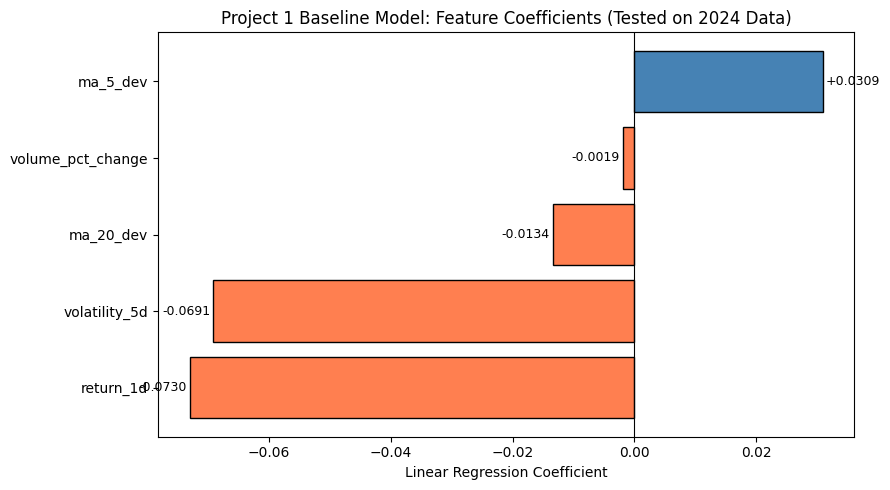

In [3]:
# Plot model coefficients (absolute impact ranking)
plot_df = coef_df.copy().sort_values('coefficient')
colors = ['steelblue' if c >= 0 else 'coral' for c in plot_df['coefficient']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(plot_df['feature'], plot_df['coefficient'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Linear Regression Coefficient')
ax.set_title('Project 1 Baseline Model: Feature Coefficients (Tested on 2024 Data)')

for bar, val in zip(bars, plot_df['coefficient']):
    ax.text(
        val + (0.0005 if val >= 0 else -0.0005),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.4f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9,
    )

plt.tight_layout()
plt.show()